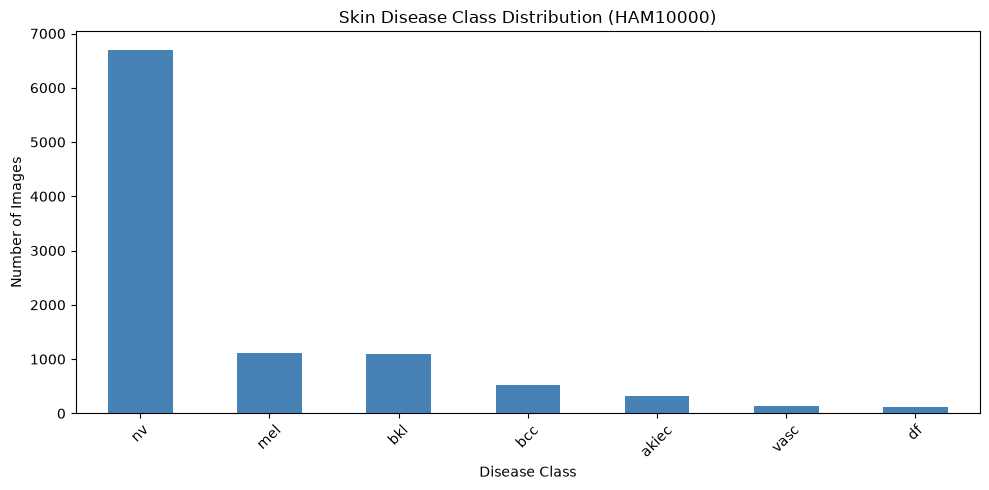

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load metadata
df = pd.read_csv('../data/raw/HAM10000_metadata.csv')

# Plot class distribution
plt.figure(figsize=(10, 5))
df['dx'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Skin Disease Class Distribution (HAM10000)')
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

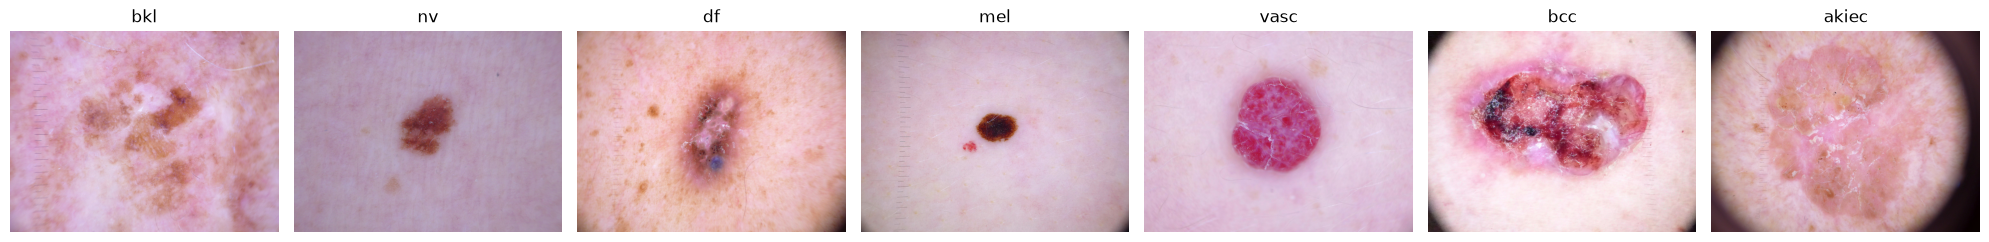

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Path to images (they're split across two folders)
img_dir1 = '../data/raw/HAM10000_images_part_1'
img_dir2 = '../data/raw/HAM10000_images_part_2'

def get_image_path(image_id):
    path1 = os.path.join(img_dir1, image_id + '.jpg')
    path2 = os.path.join(img_dir2, image_id + '.jpg')
    return path1 if os.path.exists(path1) else path2

# Get one sample image per class
classes = df['dx'].unique()
fig, axes = plt.subplots(1, len(classes), figsize=(20, 4))

for i, cls in enumerate(classes):
    sample_id = df[df['dx'] == cls]['image_id'].iloc[0]
    img_path = get_image_path(sample_id)
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [15]:
sample_img = Image.open(get_image_path(df['image_id'].iloc[0]))
print("Image size:", sample_img.size)
print("Image mode:", sample_img.mode)

# Check a few random images for consistency
import random
sample_ids = df['image_id'].sample(10, random_state=42).tolist()
for sid in sample_ids:
    img = Image.open(get_image_path(sid))
    print(sid, img.size, img.mode)

Image size: (600, 450)
Image mode: RGB
ISIC_0033272 (600, 450) RGB
ISIC_0031923 (600, 450) RGB
ISIC_0026652 (600, 450) RGB
ISIC_0030583 (600, 450) RGB
ISIC_0034010 (600, 450) RGB
ISIC_0024424 (600, 450) RGB
ISIC_0032832 (600, 450) RGB
ISIC_0026671 (600, 450) RGB
ISIC_0032389 (600, 450) RGB
ISIC_0025525 (600, 450) RGB


In [16]:
from sklearn.model_selection import train_test_split

# Get unique lesion IDs with their class (using first occurrence)
lesion_df = df.groupby('lesion_id')['dx'].first().reset_index()

# Split lesion IDs into train/val/test (70/15/15)
train_ids, temp_ids = train_test_split(
    lesion_df, test_size=0.3, stratify=lesion_df['dx'], random_state=42
)
val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.5, stratify=temp_ids['dx'], random_state=42
)

# Map back to full dataframe
train_df = df[df['lesion_id'].isin(train_ids['lesion_id'])]
val_df = df[df['lesion_id'].isin(val_ids['lesion_id'])]
test_df = df[df['lesion_id'].isin(test_ids['lesion_id'])]

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain class distribution:\n", train_df['dx'].value_counts(normalize=True))
print("\nVal class distribution:\n", val_df['dx'].value_counts(normalize=True))
print("\nTest class distribution:\n", test_df['dx'].value_counts(normalize=True))

Train size: 6981
Val size: 1532
Test size: 1502

Train class distribution:
 dx
nv       0.670821
mel      0.110729
bkl      0.110586
bcc      0.051712
akiec    0.031801
vasc     0.014181
df       0.010170
Name: proportion, dtype: float64

Val class distribution:
 dx
nv       0.664491
mel      0.112924
bkl      0.104439
bcc      0.053525
akiec    0.034595
df       0.015666
vasc     0.014360
Name: proportion, dtype: float64

Test class distribution:
 dx
nv       0.668442
bkl      0.111185
mel      0.111185
bcc      0.047270
akiec    0.034621
vasc     0.013981
df       0.013316
Name: proportion, dtype: float64


In [17]:
train_df.to_csv('../data/processed/train.csv', index=False)
val_df.to_csv('../data/processed/val.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

print("Saved successfully!")

Saved successfully!


In [19]:
import sys
sys.path.append('../src')

from utils.dataset import HAM10000Dataset
from torchvision import transforms

# Simple transform for testing (just resize + convert to tensor)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Create dataset using train_df from earlier
train_dataset = HAM10000Dataset(
    dataframe=train_df,
    img_dir1='../data/raw/HAM10000_images_part_1',
    img_dir2='../data/raw/HAM10000_images_part_2',
    transform=test_transform
)

print("Dataset size:", len(train_dataset))
print("Class mapping:", train_dataset.class_to_idx)

# Test loading one sample
image, label = train_dataset[0]
print("\nImage tensor shape:", image.shape)
print("Label:", label)

Dataset size: 6981
Class mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

Image tensor shape: torch.Size([3, 224, 224])
Label: 2


In [20]:
from torch.utils.data import DataLoader

# Training transforms - with augmentation (helps generalization + imbalance)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats, since we'll use a pretrained model
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms - NO augmentation, just resize + normalize
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Recreate datasets with proper transforms
train_dataset = HAM10000Dataset(train_df, '../data/raw/HAM10000_images_part_1', '../data/raw/HAM10000_images_part_2', transform=train_transform)
val_dataset = HAM10000Dataset(val_df, '../data/raw/HAM10000_images_part_1', '../data/raw/HAM10000_images_part_2', transform=val_test_transform)
test_dataset = HAM10000Dataset(test_df, '../data/raw/HAM10000_images_part_1', '../data/raw/HAM10000_images_part_2', transform=val_test_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Test: grab one batch
images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Sample labels:", labels[:10])

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Sample labels: tensor([2, 5, 5, 5, 5, 4, 5, 5, 5, 4])


In [21]:
import sys
sys.path.append('../src')
from models.model import create_model

model = create_model(num_classes=7, pretrained=True)
print(model.classifier)

# Quick test: pass one batch through the model
output = model(images)
print("Output shape:", output.shape)  # should be [32, 7]

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\rahul/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:05<00:00, 3.72MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)
Output shape: torch.Size([32, 7])


In [22]:
import torch
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get labels in the same order as class_to_idx mapping
class_names = train_dataset.classes  # sorted list: ['akiec','bcc','bkl','df','mel','nv','vasc']
train_labels = train_df['dx'].map(train_dataset.class_to_idx).values

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float32)

print("Classes:", class_names)
print("Class weights:", class_weights)

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class weights: tensor([ 4.4923,  2.7626,  1.2918, 14.0463,  1.2901,  0.2130, 10.0736])
